In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip '/content/drive/MyDrive/Tomato Dataset.zip' -d '/content/drive/MyDrive/Tomato Dataset_KD_T3_A0.2'

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/Tomato Dataset_KD_T3_A0.2/tomato/train/Tomato___Target_Spot/002213fb-b620-4593-b9ac-6a6cc119b100___Com.G_TgS_FL 8360.JPG  
  inflating: /content/drive/MyDrive/Tomato Dataset_KD_T3_A0.2/tomato/train/Tomato___Target_Spot/0044d10f-7062-4655-8abd-9fffc5b2f152___Com.G_TgS_FL 7908.JPG  
  inflating: /content/drive/MyDrive/Tomato Dataset_KD_T3_A0.2/tomato/train/Tomato___Target_Spot/00854623-ba28-446d-a1d5-03c0ae3f99d9___Com.G_TgS_FL 7949.JPG  
  inflating: /content/drive/MyDrive/Tomato Dataset_KD_T3_A0.2/tomato/train/Tomato___Target_Spot/0118c27a-f34a-41e1-8b2f-d2c564f83c5c___Com.G_TgS_FL 0013.JPG  
  inflating: /content/drive/MyDrive/Tomato Dataset_KD_T3_A0.2/tomato/train/Tomato___Target_Spot/0118ed61-b135-45be-ad81-7e2d54203be4___Com.G_TgS_FL 8241.JPG  
  inflating: /content/drive/MyDrive/Tomato Dataset_KD_T3_A0.2/tomato/train/Tomato___Target_Spot/0197df47-a9cb-4b6c-b72c-ac0e9af6d135___Com.G_TgS_FL 0779.J

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, regularizers, callbacks, metrics
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import load_model, Model
import os
import matplotlib.pyplot as plt
import numpy as np

In [4]:
TEACHER_MODEL_PATH  = "/content/drive/MyDrive/Model/EfficientNetB5_Test2.keras"
TRAIN_DIR           = "/content/drive/MyDrive/Tomato Dataset_KD_T3_A0.2/tomato/train"
VALIDATION_DIR      = "/content/drive/MyDrive/Tomato Dataset_KD_T3_A0.2/tomato/val"

In [6]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 10
EPOCHS_KD = 17
TEMPERATURE = 3
ALPHA = 0.2

In [7]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="rgb",
    validation_split=0.1765,
    subset="training",
    seed=0
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="rgb",
    validation_split=0.1765,
    subset="validation",
    seed=0
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=VALIDATION_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="rgb",
    shuffle=False
)

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

Found 10000 files belonging to 10 classes.
Using 8235 files for training.
Found 10000 files belonging to 10 classes.
Using 1765 files for validation.
Found 1000 files belonging to 10 classes.


In [8]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.25),
    layers.RandomBrightness(0.3),
], name="ekstrem_augmentation")

In [9]:
def create_student_model(input_shape, num_classes):
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation=None, name="student_logits")(x)
    model = models.Model(inputs, outputs, name="student_model")
    return model

In [10]:
print("Memuat Teacher Model...")
teacher_model = load_model(TEACHER_MODEL_PATH, compile=False)
teacher_model.trainable = False
print("Teacher Model Loaded.")

Memuat Teacher Model...
Teacher Model Loaded.


In [11]:
class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.dist_loss_tracker = keras.metrics.Mean(name="dist_loss")
        self.student_loss_tracker = keras.metrics.Mean(name="student_loss")

        self.accuracy_metric = keras.metrics.CategoricalAccuracy(name="accuracy")
        self.auc_metric = keras.metrics.AUC(name="auc")
        self.precision_metric = keras.metrics.Precision(name="precision")
        self.recall_metric = keras.metrics.Recall(name="recall")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.dist_loss_tracker,
            self.student_loss_tracker,
            self.accuracy_metric,
            self.auc_metric,
            self.precision_metric,
            self.recall_metric
        ]

    def compile(self, optimizer, student_loss_fn, distillation_loss_fn, alpha=0.1, temperature=3):
        super().compile(optimizer=optimizer)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data
        x_teacher = tf.image.resize(x, [456, 456])
        teacher_predictions = self.teacher(x_teacher, training=False)

        with tf.GradientTape() as tape:
            student_logits = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_logits)
            student_probs_temp = tf.nn.softmax(student_logits / self.temperature, axis=1)
            eps = 1e-7
            teacher_probs_safe = tf.clip_by_value(teacher_predictions, eps, 1.0 - eps)
            teacher_pseudo_logits = tf.math.log(teacher_probs_safe)
            teacher_probs_temp = tf.nn.softmax(teacher_pseudo_logits / self.temperature, axis=1)
            distillation_loss = self.distillation_loss_fn(teacher_probs_temp, student_probs_temp)
            distillation_loss = distillation_loss * (self.temperature ** 2)
            total_loss = (self.alpha * distillation_loss) + ((1 - self.alpha) * student_loss)
        gradients = tape.gradient(total_loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.student.trainable_variables))
        self.total_loss_tracker.update_state(total_loss)
        self.dist_loss_tracker.update_state(distillation_loss)
        self.student_loss_tracker.update_state(student_loss)
        student_probs = tf.nn.softmax(student_logits)
        self.accuracy_metric.update_state(y, student_probs)
        self.auc_metric.update_state(y, student_probs)
        self.precision_metric.update_state(y, student_probs)
        self.recall_metric.update_state(y, student_probs)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data

        x_teacher = tf.image.resize(x, [456, 456])
        teacher_predictions = self.teacher(x_teacher, training=False)

        student_logits = self.student(x, training=False)
        student_loss = self.student_loss_fn(y, student_logits)
        eps = 1e-7
        teacher_probs_safe = tf.clip_by_value(teacher_predictions, eps, 1.0 - eps)
        teacher_pseudo_logits = tf.math.log(teacher_probs_safe)

        teacher_probs_temp = tf.nn.softmax(teacher_pseudo_logits / self.temperature, axis=1)
        student_probs_temp = tf.nn.softmax(student_logits / self.temperature, axis=1)

        distillation_loss = self.distillation_loss_fn(teacher_probs_temp, student_probs_temp)
        distillation_loss = distillation_loss * (self.temperature ** 2)
        total_loss = (self.alpha * distillation_loss) + ((1 - self.alpha) * student_loss)

        self.total_loss_tracker.update_state(total_loss)
        self.dist_loss_tracker.update_state(distillation_loss)
        self.student_loss_tracker.update_state(student_loss)

        student_probs = tf.nn.softmax(student_logits)
        self.accuracy_metric.update_state(y, student_probs)
        self.auc_metric.update_state(y, student_probs)
        self.precision_metric.update_state(y, student_probs)
        self.recall_metric.update_state(y, student_probs)

        return {m.name: m.result() for m in self.metrics}

In [12]:
import time
from datetime import timedelta
import tensorflow as tf
import keras

class TimeTrackingCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        self.epoch_times = []
        self.start_time = None

    def on_epoch_begin(self, epoch, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.start_time
        self.epoch_times.append(epoch_time)
        print(f"\nEpoch {epoch+1} selesai dalam {epoch_time:.2f} detik")

time_callback_kd = TimeTrackingCallback()

student_model = create_student_model((*IMAGE_SIZE, 3), NUM_CLASSES)
distiller = Distiller(student=student_model, teacher=teacher_model)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_total_loss",
    patience=8,
    restore_best_weights=True,
    mode="min"
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_total_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1,
    mode="min"
)

distiller.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    student_loss_fn=keras.losses.CategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=ALPHA,
    temperature=TEMPERATURE
)

print("\nMemulai Pelatihan Model Murid (Knowledge Distillation)...")

history = distiller.fit(
    train_dataset,
    epochs=EPOCHS_KD,
    validation_data=validation_dataset,
    callbacks=[early_stopping, reduce_lr, time_callback_kd]
)

if len(time_callback_kd.epoch_times) > 0:
    avg_epoch_time = sum(time_callback_kd.epoch_times) / len(time_callback_kd.epoch_times)
    total_time = sum(time_callback_kd.epoch_times)

    print("\n" + "="*50)
    print("HASIL WAKTU PELATIHAN KD")
    print("="*50)
    print(f"Total epoch yang dijalankan: {len(time_callback_kd.epoch_times)}")
    print(f"Waktu rata-rata per epoch:  {avg_epoch_time:.2f} detik ({avg_epoch_time/60:.2f} menit)")
    print(f"Total waktu pelatihan:      {total_time:.2f} detik ({total_time/60:.2f} menit)")
    print(f"Waktu tercepat:            {min(time_callback_kd.epoch_times):.2f} detik")
    print(f"Waktu terlama:             {max(time_callback_kd.epoch_times):.2f} detik")
    print("="*50)
else:
    print("\nTidak ada data waktu epoch yang tersedia.")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Memulai Pelatihan Model Murid (Knowledge Distillation)...
Epoch 1/17
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4958 - auc: 0.8521 - dist_loss: 5.7241 - precision: 0.5761 - recall: 0.4247 - student_loss: 1.6852 - total_loss: 2.4930
Epoch 1 selesai dalam 422.35 detik
258/258 ━━━━━━━━━━━━━━━━━━━━ 422s 1s/step - accuracy: 0.6265 - auc: 0.9267 - dist_loss: 4.1305 - precision: 0.6980 - recall: 0.5715 - student_loss: 1.1869 - total_loss: 1.7756 - val_accuracy: 0.8113 - val_auc: 0.9783 - val_dist_loss: 2.5830 - val_precision: 0.8822 - val_recall: 0.7343 - val_student_loss: 0.6088 - val_total_loss: 1.0036 - learning_rate: 0.0010
Epoch 2/17
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7499 - auc: 0.9678 - dist_loss: 2.7543 - precision: 0.7940 - recall: 0.7182 - student_loss: 0.7359 - total_loss: 1.1396
Epoch 2 selesai dalam 360.65 detik
258/258 ━━━━━━━━━━━━━━━━━━━━ 361s 1s/step - accuracy: 0.7627 - auc: 0.9696 - dist_loss: 

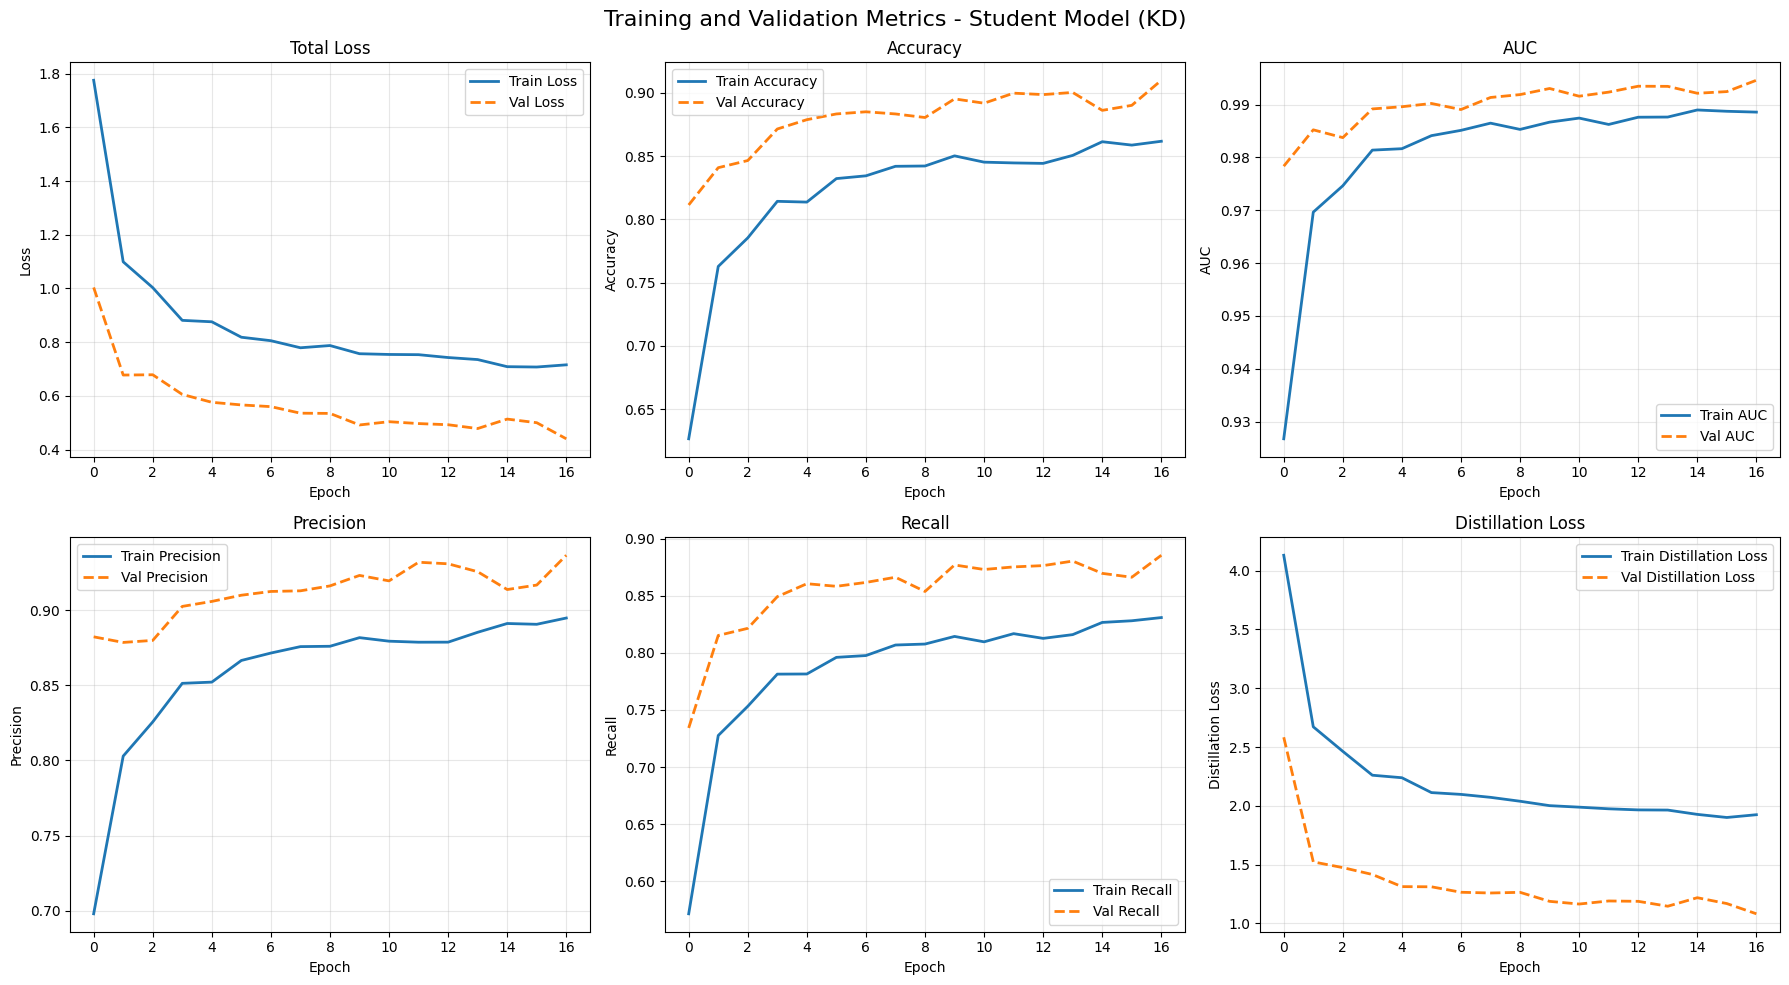


=== 📊 Evaluasi Test Set (Student KD) ===
32/32 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.8980 - auc: 0.9943 - dist_loss: 1.1929 - precision: 0.9203 - recall: 0.8780 - student_loss: 0.2858 - total_loss: 0.4672
Test Results: {'total_loss': 0.4672488272190094, 'dist_loss': 1.192850947380066, 'student_loss': 0.2858482897281647, 'accuracy': 0.8980000019073486, 'auc': 0.994304895401001, 'precision': 0.9203354120254517, 'recall': 0.878000020980835}


In [13]:
import matplotlib.pyplot as plt

def plot_kd_metrics_complete(history):
    plt.figure(figsize=(18, 10))
    plt.suptitle('Training and Validation Metrics - Student Model (KD)', fontsize=16)

    plt.subplot(2, 3, 1)
    plt.plot(history.history['total_loss'], label='Train Loss', linewidth=2)
    plt.plot(history.history['val_total_loss'], label='Val Loss', linewidth=2, linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title('Total Loss')

    plt.subplot(2, 3, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title('Accuracy')

    plt.subplot(2, 3, 3)
    plt.plot(history.history['auc'], label='Train AUC', linewidth=2)
    plt.plot(history.history['val_auc'], label='Val AUC', linewidth=2, linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title('AUC')

    plt.subplot(2, 3, 4)
    plt.plot(history.history['precision'], label='Train Precision', linewidth=2)
    plt.plot(history.history['val_precision'], label='Val Precision', linewidth=2, linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title('Precision')

    plt.subplot(2, 3, 5)
    plt.plot(history.history['recall'], label='Train Recall', linewidth=2)
    plt.plot(history.history['val_recall'], label='Val Recall', linewidth=2, linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Recall')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title('Recall')

    plt.subplot(2, 3, 6)
    plt.plot(history.history['dist_loss'], label='Train Distillation Loss', linewidth=2)
    if 'val_dist_loss' in history.history:
        plt.plot(history.history['val_dist_loss'], label='Val Distillation Loss', linewidth=2, linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Distillation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title('Distillation Loss')

    plt.tight_layout()
    plt.show()

plot_kd_metrics_complete(history)

print("\n=== 📊 Evaluasi Test Set (Student KD) ===")
test_results = distiller.evaluate(test_dataset)
print("Test Results:", dict(zip(distiller.metrics_names, test_results)))

In [14]:
print("\n--- Menyimpan Model ---")
save_path = "/content/drive/MyDrive/Model/EfficientNetB0_KD_T3_A0.2.keras"
student_model.save(save_path)
print(f"Model berhasil disimpan di: {save_path}")


--- Menyimpan Model ---
Model berhasil disimpan di: /content/drive/MyDrive/Model/EfficientNetB0_KD_T3_A0.2.keras


In [15]:
print("\n" + "="*50)
print("🔍 STUDENT MODEL (KD) PERFORMANCE ANALYSIS")
print("="*50)

size_mb = os.path.getsize(save_path)/(1024*1024)
print(f"📦 Model Size     : {size_mb:.2f} MB")

input_shape = (1, IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
dummy = tf.random.normal(input_shape)

print(f"\n⏱️  Testing Inference Speed (IMAGE_SIZE={IMAGE_SIZE})...")

print("  Warming up...")
for _ in range(10):
    _ = student_model(dummy, training=False)

n_test = 100
latencies = []

print(f"  Testing {n_test} images Student Model (KD)...")
start_total = time.time()

for i in range(n_test):
    start = time.time()
    _ = student_model(dummy, training=False)
    latency = (time.time() - start) * 1000
    latencies.append(latency)

end_total = time.time()

avg_latency = np.mean(latencies[10:])
min_latency = np.min(latencies[10:])
max_latency = np.max(latencies[10:])
throughput = 1000 / avg_latency

print(f"\n📈 INFERENCE RESULTS Student Model (KD):")
print(f"  Average Latency : {avg_latency:.2f} ms **PER IMAGE**")
print(f"  Min Latency     : {min_latency:.2f} ms")
print(f"  Max Latency     : {max_latency:.2f} ms")
print(f"  Throughput      : {throughput:.1f} images/second")
print(f"  Total {n_test} imgs: {(end_total-start_total)*1000:.2f} ms")

print("\n" + "="*50)


🔍 STUDENT MODEL (KD) PERFORMANCE ANALYSIS
📦 Model Size     : 16.93 MB

⏱️  Testing Inference Speed (IMAGE_SIZE=(224, 224))...
  Warming up...
  Testing 100 images Student Model (KD)...

📈 INFERENCE RESULTS Student Model (KD):
  Average Latency : 369.51 ms **PER IMAGE**
  Min Latency     : 313.14 ms
  Max Latency     : 665.31 ms
  Throughput      : 2.7 images/second
  Total 100 imgs: 37216.58 ms

